# Text mining społeczności muzycznych Reddita

Notebook przedstawia analizę NLP komentarzy pochodzących z wybranych subredditów muzycznych. Celem analizy jest porównanie języka, sentymentu oraz głównych tematów dyskusji w społecznościach skupionych wokół różnych gatunków muzycznych.

Analiza obejmuje trzy główne obszary: preprocessing tekstu, identyfikację charakterystycznych słów i fraz, analizę sentymentu oraz modelowanie tematów z wykorzystaniem LDA.

## 1. Przygotowanie środowiska

W tej części importowane są biblioteki, definiowane ścieżki zapisu wyników oraz ustawiany jest jednolity styl wizualizacji. Notebook zapisuje tabele do folderu `../outputs/reports`, a wykresy do folderu `../outputs/figures`.

In [ ]:
from pathlib import Path
from collections import Counter
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

warnings.filterwarnings("ignore")

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

try:
    import spacy
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
    USE_SPACY = True
except Exception:
    nlp = None
    USE_SPACY = False

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

DATA_PATH = Path("../data/processed/all_subreddits_sample.csv")
FIGURES_DIR = Path("../outputs/figures")
REPORTS_DIR = Path("../outputs/reports")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model językowy spaCy dostępny: {USE_SPACY}")

In [ ]:
# Checkpoint configuration
CHECKPOINT_DIR = Path("../data/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Checkpoint dir: {CHECKPOINT_DIR.resolve()}")

## 2. Wczytanie danych

Dane zawierają komentarze z wybranych subredditów muzycznych. W dalszej części notebooka zakładane jest, że podstawowymi kolumnami są co najmniej: `subreddit`, `body` oraz `author`.

In [5]:
df_raw = pd.read_csv(DATA_PATH)

required_columns = {"subreddit", "body", "author"}
missing_columns = required_columns - set(df_raw.columns)
if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

basic_info = pd.DataFrame({
    "metryka": ["liczba wierszy", "liczba kolumn", "liczba subredditów"],
    "wartość": [len(df_raw), df_raw.shape[1], df_raw["subreddit"].nunique()]
})

display(basic_info)
display(df_raw.head())

,metryka,wartość
0,liczba wierszy,2544183
1,liczba kolumn,10
2,liczba subredditów,4


,comment_id,author,body,subreddit,score,created_utc,parent_id,link_id,controversiality,gilded
0,fk5omrz,Moron_on_Oxy-,Read that Baby Keem had a few tweets complaini...,hiphopheads,2,1583884815,t3_fglr4p,t3_fglr4p,0,0
1,fk5ono1,superchingonguey,Yeah I stumbled upon her about a year ago. She...,hiphopheads,2,1583884830,t1_fk5o56t,t3_fgnnun,0,0
2,fk5osck,Aniceguy96,"For sure Billy has more energy, Ka puts me to ...",hiphopheads,1,1583884906,t1_fk5mi66,t3_fglr4p,0,0
3,fk5oslg,Sushieatinbeast,Passion of the weiss is for the culture. I've ...,hiphopheads,20,1583884910,t3_fgihaz,t3_fgihaz,0,0
4,fk5ourg,DocterJohnSmith,"Wifey Riddim, Swerve N Skid, The Lane, Naila, ...",hiphopheads,2,1583884946,t1_fk5o548,t3_fglr4p,0,0


In [ ]:
# Save df_raw checkpoint
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_raw_checkpoint_path = CHECKPOINT_DIR / "df_raw_checkpoint.pkl"
df_raw.to_pickle(df_raw_checkpoint_path)
print(f"Zapisano df_raw do: {df_raw_checkpoint_path}")
print(f"df_raw shape: {df_raw.shape}")

In [ ]:
# Load df_raw from checkpoint if available
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_raw_checkpoint_path = CHECKPOINT_DIR / "df_raw_checkpoint.pkl"
if df_raw_checkpoint_path.exists():
    df_raw = pd.read_pickle(df_raw_checkpoint_path)
    print(f"Wczytano df_raw z: {df_raw_checkpoint_path}")
    print(f"df_raw shape: {df_raw.shape}")
else:
    print(f"Brak checkpointu: {df_raw_checkpoint_path}")

## 3. Opis procesu preprocessingowego

Preprocessing został uporządkowany tak, aby wszystkie analizy opierały się na tym samym, oczyszczonym zbiorze danych. Kolejność działań jest następująca:

1. usunięcie botów oraz kont automatycznych,
2. usunięcie komentarzy technicznych, usuniętych i niedostępnych (`[deleted]`, `[removed]`),
3. zamiana tekstu na małe litery,
4. usunięcie adresów URL,
5. usunięcie znaków specjalnych i nadmiarowych spacji,
6. tokenizacja,
7. usunięcie stopwords oraz dodatkowych słów o niskiej wartości analitycznej,
8. lematyzacja z użyciem spaCy, a w przypadku braku modelu językowego — stemming z użyciem `PorterStemmer`.

Taki układ ogranicza wpływ szumu technicznego na późniejsze wyniki TF-IDF, sentymentu oraz LDA.

In [21]:
from tqdm import tqdm
import time

BOTS = {
    "MusicMirrorMan", "HHHRobot", "NoGoogleAMPBot", "ReconEG", "AutoModerator",
    "RemindMeBot", "SaveVideoBot", "DownloadVideoBot", "LinkifyBot", "auddbot",
    "songbot", "lyricsbot", "MusicIdentifierBot", "SpotifyPreviewBot", "RepostSleuthBot",
    "MAGIC_EYE_BOT", "DuplicateDestroyer", "GrammarBotElite", "ShakespeareBot",
    "WikipediaSummaryBot", "HelpfulBot", "AssistantBot", "FreshReleaseBot", "AlbumDropBot",
    "TrackReleaseBot", "MusicNewsBot", "HipHopBot", "IndieBot", "PopMusicBot",
    "TwitterStatusBot", "YouTubeBot", "RedditVideoBot", "TotesMessenger", "AntiSpamBot",
    "BotDefense"
}

MODERATION_PATTERNS = [
    r"hello, thanks for posting",
    r"your submission has been removed",
    r"this post has been removed",
    r"i am a bot",
    r"beep boop",
    r"automoderator",
    r"please contact the moderators",
]

base_stopwords = set(stopwords.words("english"))
extra_stopwords = {
    "like", "just", "get", "got", "one", "know", "think", "really", "would",
    "also", "even", "much", "still", "way", "good", "make", "people", "time",
    "music", "song", "songs", "album", "albums", "artist", "artists", "track", "tracks",
    "band", "bands", "https", "http", "www", "com", "reddit", "amp", "subreddit"
}
STOP_WORDS = base_stopwords | extra_stopwords
stemmer = PorterStemmer()


def log_step(message: str, start_time=None):
    now = time.strftime("%H:%M:%S")
    if start_time is None:
        print(f"[{now}] {message}")
    else:
        elapsed = time.time() - start_time
        print(f"[{now}] {message} | czas: {elapsed:.2f} s")


def remove_urls(text: str) -> str:
    return re.sub(r"http\S+|www\.\S+", " ", text)


def clean_text_basic(text: str) -> str:
    text = str(text).lower()
    text = remove_urls(text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_texts(texts: pd.Series) -> list[list[str]]:
    step_start = time.time()
    log_step("Czyszczenie tekstów przed tokenizacją...")

    cleaned_texts = texts.fillna("").astype(str).map(clean_text_basic).tolist()

    log_step(
        f"Zakończono czyszczenie tekstów. Liczba tekstów: {len(cleaned_texts):,}",
        step_start
    )

    if USE_SPACY:
        log_step("Rozpoczynam spaCy preprocessing...")

        processed = []
        spacy_start = time.time()

        for doc in tqdm(
            nlp.pipe(cleaned_texts, batch_size=500),
            total=len(cleaned_texts),
            desc="spaCy preprocessing",
            unit="komentarz"
        ):
            tokens = [
                token.lemma_.lower()
                for token in doc
                if token.is_alpha
                and token.lemma_.lower() not in STOP_WORDS
                and len(token.lemma_) > 2
            ]
            processed.append(tokens)

        log_step("Zakończono spaCy preprocessing", spacy_start)
        return processed

    log_step("Rozpoczynam NLTK preprocessing...")

    processed = []
    nltk_start = time.time()

    for text in tqdm(
        cleaned_texts,
        total=len(cleaned_texts),
        desc="NLTK preprocessing",
        unit="komentarz"
    ):
        tokens = [
            stemmer.stem(token)
            for token in word_tokenize(text)
            if token.isalpha()
            and token not in STOP_WORDS
            and len(token) > 2
        ]
        processed.append(tokens)

    log_step("Zakończono NLTK preprocessing", nltk_start)
    return processed


def filter_dataset(df: pd.DataFrame) -> pd.DataFrame:
    total_start = time.time()

    log_step("Rozpoczynam filtrowanie danych...")
    log_step(f"Liczba rekordów wejściowych: {len(df):,}")

    filtered = df.copy()

    step_start = time.time()
    filtered["body"] = filtered["body"].fillna("").astype(str)
    filtered["author"] = filtered["author"].fillna("unknown").astype(str)
    log_step("Uzupełniono braki w kolumnach body i author", step_start)

    step_start = time.time()
    removed_mask = (
        filtered["body"]
        .str.strip()
        .str.lower()
        .isin(["[deleted]", "[removed]", "deleted", "removed", ""])
    )
    log_step(f"Zidentyfikowano usunięte komentarze: {removed_mask.sum():,}", step_start)

    step_start = time.time()
    bot_mask = (
        filtered["author"].isin(BOTS)
        | filtered["author"].str.lower().str.contains("bot", na=False)
    )
    log_step(f"Zidentyfikowano boty: {bot_mask.sum():,}", step_start)

    step_start = time.time()
    moderation_mask = filtered["body"].str.contains(
        "|".join(MODERATION_PATTERNS),
        case=False,
        na=False,
        regex=True
    )
    log_step(f"Zidentyfikowano wiadomości moderacyjne: {moderation_mask.sum():,}", step_start)

    step_start = time.time()
    filtered = filtered.loc[
        ~removed_mask & ~bot_mask & ~moderation_mask
    ].copy()
    log_step(f"Pozostało po podstawowym filtrowaniu: {len(filtered):,}", step_start)

    step_start = time.time()
    filtered["clean_text"] = filtered["body"].map(clean_text_basic)
    log_step("Utworzono kolumnę clean_text", step_start)

    step_start = time.time()
    before_empty = len(filtered)
    filtered = filtered[filtered["clean_text"].str.len() > 0].copy()
    log_step(
        f"Usunięto puste clean_text: {before_empty - len(filtered):,}. Pozostało: {len(filtered):,}",
        step_start
    )

    step_start = time.time()
    log_step("Rozpoczynam tokenizację i lematyzację/stemming — to najdłuższy etap.")
    filtered["tokens"] = preprocess_texts(filtered["body"])
    log_step("Utworzono kolumnę tokens", step_start)

    step_start = time.time()
    filtered["processed_text"] = filtered["tokens"].map(lambda tokens: " ".join(tokens))
    filtered["token_count"] = filtered["tokens"].map(len)
    log_step("Utworzono kolumny processed_text i token_count", step_start)

    step_start = time.time()
    before_tokens = len(filtered)
    filtered = filtered[filtered["token_count"] > 0].copy()
    log_step(
        f"Usunięto rekordy bez tokenów: {before_tokens - len(filtered):,}. Finalnie: {len(filtered):,}",
        step_start
    )

    log_step("Cały preprocessing zakończony", total_start)

    return filtered.reset_index(drop=True)


overall_start = time.time()

df = filter_dataset(df_raw)

preprocessing_summary = pd.DataFrame({
    "etap": ["dane początkowe", "dane po czyszczeniu", "usunięte rekordy"],
    "liczba_komentarzy": [len(df_raw), len(df), len(df_raw) - len(df)]
})

preprocessing_summary.to_csv(
    REPORTS_DIR / "text_mining_preprocessing_summary.csv",
    index=False
)

log_step("Zapisano podsumowanie preprocessingu do CSV", overall_start)

display(preprocessing_summary)

print("Dostępne kolumny:")
print(df.columns.tolist())

columns_to_show = [
    col for col in ["subreddit", "author", "body", "tokens"]
    if col in df.columns
]

display(df[columns_to_show].head())

[14:38:14] Rozpoczynam filtrowanie danych...
[14:38:14] Liczba rekordów wejściowych: 2,544,183
[14:38:14] Uzupełniono braki w kolumnach body i author | czas: 0.22 s
[14:38:17] Zidentyfikowano usunięte komentarze: 0 | czas: 2.59 s
[14:38:18] Zidentyfikowano boty: 44,561 | czas: 0.84 s
[14:38:39] Zidentyfikowano wiadomości moderacyjne: 41,541 | czas: 21.76 s
[14:38:40] Pozostało po podstawowym filtrowaniu: 2,492,707 | czas: 0.36 s
[14:39:03] Utworzono kolumnę clean_text | czas: 23.20 s
[14:39:04] Usunięto puste clean_text: 6,695. Pozostało: 2,486,012 | czas: 0.85 s
[14:39:04] Rozpoczynam tokenizację i lematyzację/stemming — to najdłuższy etap.
[14:39:04] Czyszczenie tekstów przed tokenizacją...
[14:39:27] Zakończono czyszczenie tekstów. Liczba tekstów: 2,486,012 | czas: 23.68 s
[14:39:27] Rozpoczynam spaCy preprocessing...


spaCy preprocessing: 100%|██████████| 2486012/2486012 [1:41:23<00:00, 408.62komentarz/s]  


[16:20:51] Zakończono spaCy preprocessing | czas: 6083.89 s
[16:20:52] Utworzono kolumnę tokens | czas: 6107.96 s
[16:20:54] Utworzono kolumny processed_text i token_count | czas: 1.90 s
[16:21:00] Usunięto rekordy bez tokenów: 15,498. Finalnie: 2,470,514 | czas: 6.21 s
[16:21:00] Cały preprocessing zakończony | czas: 6166.07 s
[16:21:00] Zapisano podsumowanie preprocessingu do CSV | czas: 6166.10 s


,etap,liczba_komentarzy
0,dane początkowe,2544183
1,dane po czyszczeniu,2470514
2,usunięte rekordy,73669


Dostępne kolumny:
['comment_id', 'author', 'body', 'subreddit', 'score', 'created_utc', 'parent_id', 'link_id', 'controversiality', 'gilded', 'clean_text', 'tokens', 'processed_text', 'token_count']


,subreddit,author,body,tokens
0,hiphopheads,Moron_on_Oxy-,Read that Baby Keem had a few tweets complaini...,"[read, baby, keem, tweet, complain, right, coa..."
1,hiphopheads,superchingonguey,Yeah I stumbled upon her about a year ago. She...,"[yeah, stumble, upon, year, ago, little, corny..."
2,hiphopheads,Aniceguy96,"For sure Billy has more energy, Ka puts me to ...","[sure, billy, energy, put, sleep, tell, enough..."
3,hiphopheads,Sushieatinbeast,Passion of the weiss is for the culture. I've ...,"[passion, weiss, culture, discover, shit]"
4,hiphopheads,DocterJohnSmith,"Wifey Riddim, Swerve N Skid, The Lane, Naila, ...","[wifey, riddim, swerve, skid, lane, naila, bla..."


In [ ]:
# Save preprocessed df checkpoint
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_checkpoint_path = CHECKPOINT_DIR / "df_preprocessed_checkpoint.pkl"
df.to_pickle(df_checkpoint_path)
print(f"Zapisano df do: {df_checkpoint_path}")
print(f"df shape: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")

In [ ]:
# Load preprocessed df from checkpoint if available
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
df_checkpoint_path = CHECKPOINT_DIR / "df_preprocessed_checkpoint.pkl"
if df_checkpoint_path.exists():
    df = pd.read_pickle(df_checkpoint_path)
    print(f"Wczytano df z: {df_checkpoint_path}")
    print(f"df shape: {df.shape}")
    print(f"Kolumny: {df.columns.tolist()}")
else:
    print(f"Brak checkpointu: {df_checkpoint_path}")

### Komentarz metodologiczny

Czyszczenie danych zostało wykonane przed właściwą analizą tekstu, dzięki czemu wyniki nie są zniekształcane przez automatyczne komentarze botów, komunikaty moderacyjne oraz usunięte treści. Jest to szczególnie ważne w analizie Reddita, ponieważ boty i automatyczne odpowiedzi mogą sztucznie zwiększać częstość określonych słów lub fraz.

## 4. Najczęstsze słowa i bigramy

Pierwszy etap analizy tekstowej obejmuje identyfikację najczęściej występujących słów i bigramów w poszczególnych społecznościach. Ta część pozwala uchwycić podstawowe różnice słownikowe między subredditami.

,subreddit,item,count
0,Metal,metal,27070
1,Metal,listen,12286
2,Metal,death,10682
3,Metal,see,9642
4,Metal,love,9577
5,Metal,black,9570
6,Metal,year,9052
7,Metal,great,8634
8,Metal,new,8543
9,Metal,well,8412


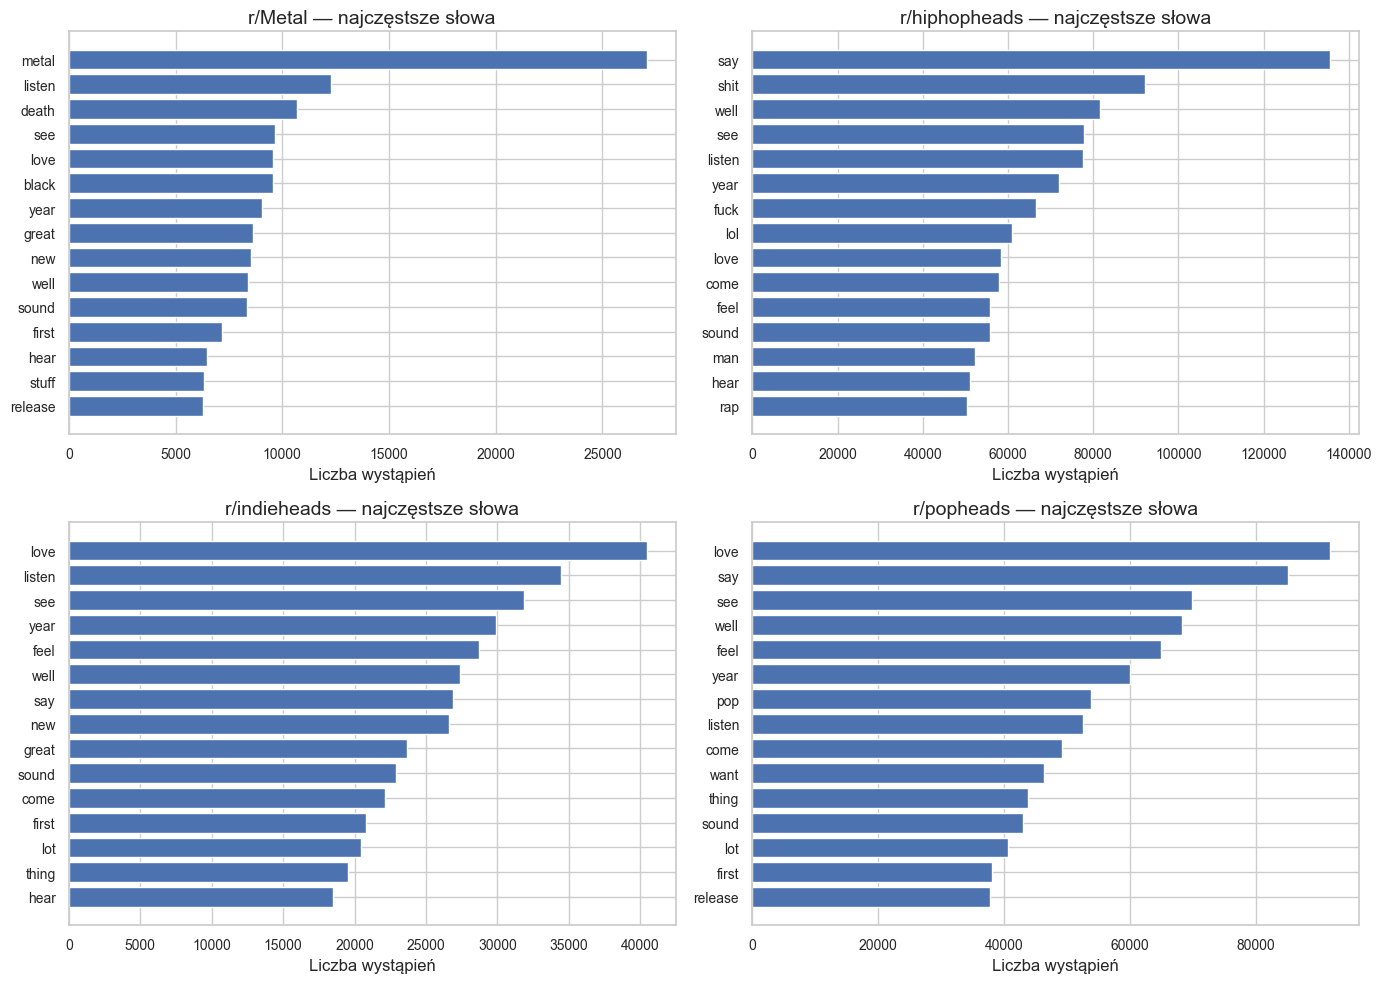

In [22]:
def get_top_items_by_subreddit(df: pd.DataFrame, column: str, top_n: int = 15) -> pd.DataFrame:
    rows = []
    for subreddit, group in df.groupby("subreddit"):
        all_items = []
        for items in group[column]:
            all_items.extend(items)
        for item, count in Counter(all_items).most_common(top_n):
            rows.append({"subreddit": subreddit, "item": item, "count": count})
    return pd.DataFrame(rows)


top_words = get_top_items_by_subreddit(df, "tokens", top_n=15)
top_words.to_csv(REPORTS_DIR / "top_words_by_subreddit.csv", index=False)
display(top_words.head(20))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, top_words.groupby("subreddit")):
    plot_data = group.sort_values("count", ascending=True)
    ax.barh(plot_data["item"], plot_data["count"])
    ax.set_title(f"r/{subreddit} — najczęstsze słowa")
    ax.set_xlabel("Liczba wystąpień")
    ax.set_ylabel("")

for ax in axes[len(top_words["subreddit"].unique()):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

,subreddit,item,count
0,Metal,black metal,4521
1,Metal,death metal,4241
2,Metal,last year,1315
3,Metal,year ago,1097
4,Metal,heavy metal,1061
5,Metal,power metal,981
6,Metal,see live,792
7,Metal,never hear,619
8,Metal,look forward,601
9,Metal,full length,583


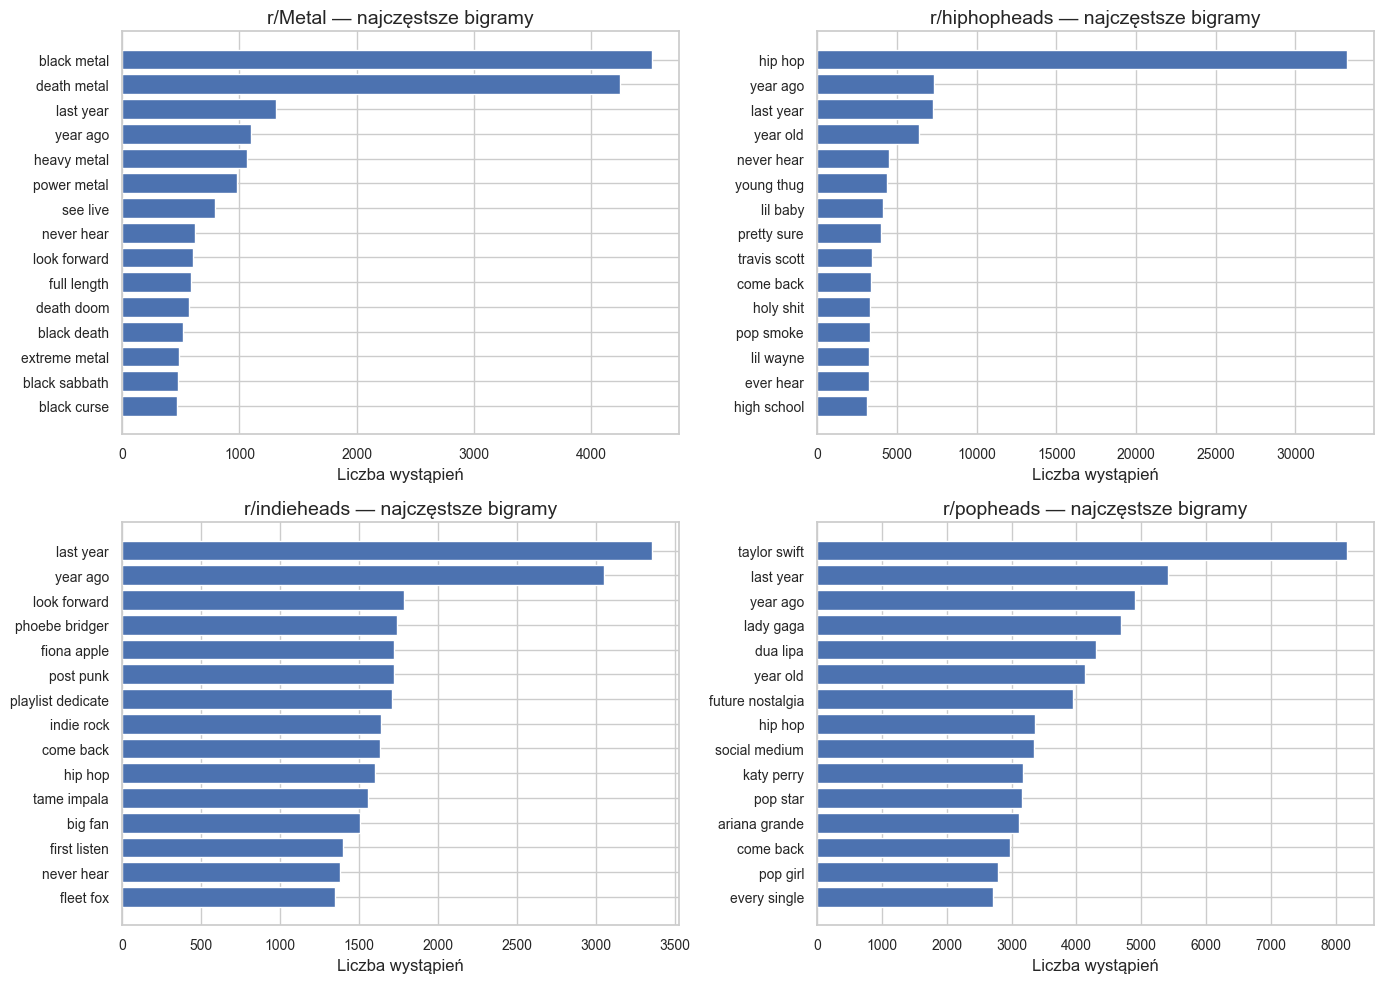

In [23]:
df["bigrams"] = df["tokens"].map(lambda tokens: [" ".join(bg) for bg in ngrams(tokens, 2)])
top_bigrams = get_top_items_by_subreddit(df, "bigrams", top_n=15)
top_bigrams.to_csv(REPORTS_DIR / "top_bigrams_by_subreddit.csv", index=False)
display(top_bigrams.head(20))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, top_bigrams.groupby("subreddit")):
    plot_data = group.sort_values("count", ascending=True)
    ax.barh(plot_data["item"], plot_data["count"])
    ax.set_title(f"r/{subreddit} — najczęstsze bigramy")
    ax.set_xlabel("Liczba wystąpień")
    ax.set_ylabel("")

for ax in axes[len(top_bigrams["subreddit"].unique()):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_top_bigrams.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretacja najczęstszych słów i bigramów

Najczęstsze słowa pokazują ogólny zakres tematów obecnych w komentarzach, natomiast bigramy pozwalają lepiej uchwycić kontekst wypowiedzi. W analizie społeczności muzycznych szczególnie istotne są powtarzające się nazwy wykonawców, gatunków, wydarzeń, wydań płytowych oraz określenia wartościujące. Różnice między subredditami mogą wskazywać na odmienne style dyskusji: część społeczności może częściej koncentrować się na konkretnych artystach, inne na rekomendacjach, premierach lub ocenach estetycznych.

## 5. Analiza TF-IDF

Sama częstość występowania słów nie zawsze pokazuje, które wyrazy są charakterystyczne dla danej społeczności. Dlatego zastosowano TF-IDF, który podwyższa wagę słów częstych w danym subreddicie, ale relatywnie rzadszych w pozostałych częściach korpusu.

,subreddit,rank,term,tfidf_score
0,Metal,1,metal,0.4626
1,Metal,2,listen,0.2099
2,Metal,3,death,0.1825
3,Metal,4,see,0.1648
4,Metal,5,love,0.1637
5,Metal,6,black,0.1635
6,Metal,7,year,0.1547
7,Metal,8,great,0.1475
8,Metal,9,new,0.1460
9,Metal,10,well,0.1437


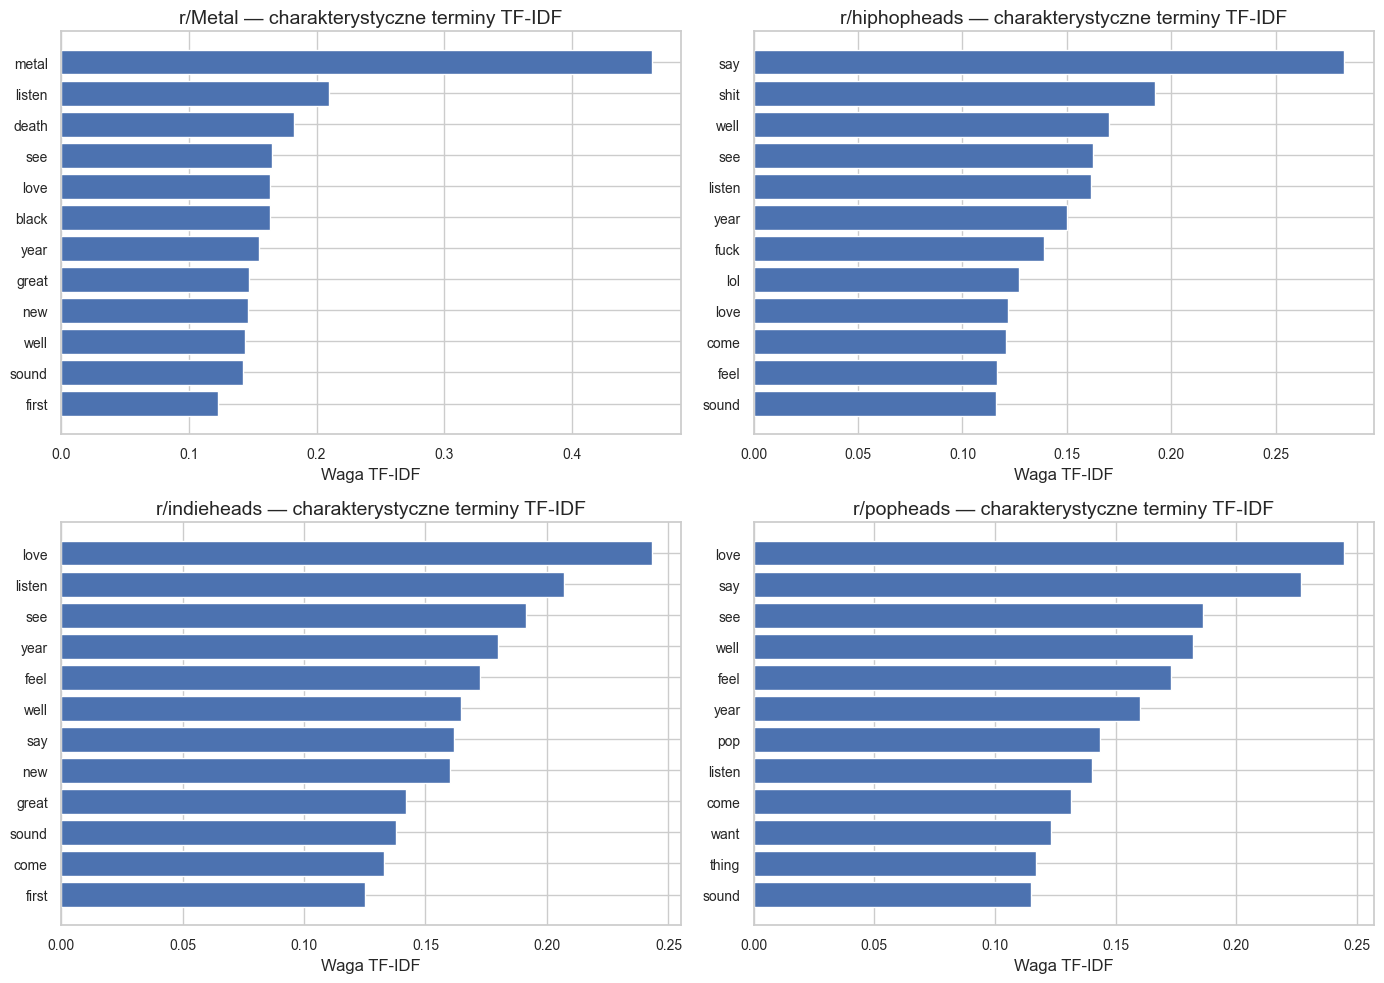

In [24]:
subreddit_documents = (
    df.groupby("subreddit")["processed_text"]
    .apply(lambda texts: " ".join(texts))
    .reset_index()
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(subreddit_documents["processed_text"])
feature_names = np.array(vectorizer.get_feature_names_out())

rows = []
for idx, subreddit in enumerate(subreddit_documents["subreddit"]):
    scores = tfidf_matrix[idx].toarray().ravel()
    top_indices = scores.argsort()[::-1][:20]
    for rank, feature_idx in enumerate(top_indices, start=1):
        rows.append({
            "subreddit": subreddit,
            "rank": rank,
            "term": feature_names[feature_idx],
            "tfidf_score": round(float(scores[feature_idx]), 4)
        })

tfidf_results = pd.DataFrame(rows)
tfidf_results.to_csv(REPORTS_DIR / "tfidf_characteristic_terms_by_subreddit.csv", index=False)
display(tfidf_results.head(40))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, tfidf_results.groupby("subreddit")):
    plot_data = group.head(12).sort_values("tfidf_score", ascending=True)
    ax.barh(plot_data["term"], plot_data["tfidf_score"])
    ax.set_title(f"r/{subreddit} — charakterystyczne terminy TF-IDF")
    ax.set_xlabel("Waga TF-IDF")
    ax.set_ylabel("")

for ax in axes[len(tfidf_results["subreddit"].unique()):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_tfidf_by_subreddit.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretacja TF-IDF

TF-IDF pozwala przejść od ogólnej popularności słów do identyfikacji terminów wyróżniających konkretne społeczności. Jeżeli dany subreddit ma wysokie wartości TF-IDF dla nazw gatunków, artystów albo określonych typów wypowiedzi, można traktować to jako sygnał jego specyficznego profilu tematycznego. W porównaniu z prostą listą najczęstszych słów analiza TF-IDF lepiej pokazuje różnice między fandomami.

## 6. Word clouds

Chmury słów służą jako wizualne podsumowanie słownictwa dominującego w poszczególnych subredditach. Nie zastępują one analizy ilościowej, ale ułatwiają szybkie porównanie profili językowych społeczności.

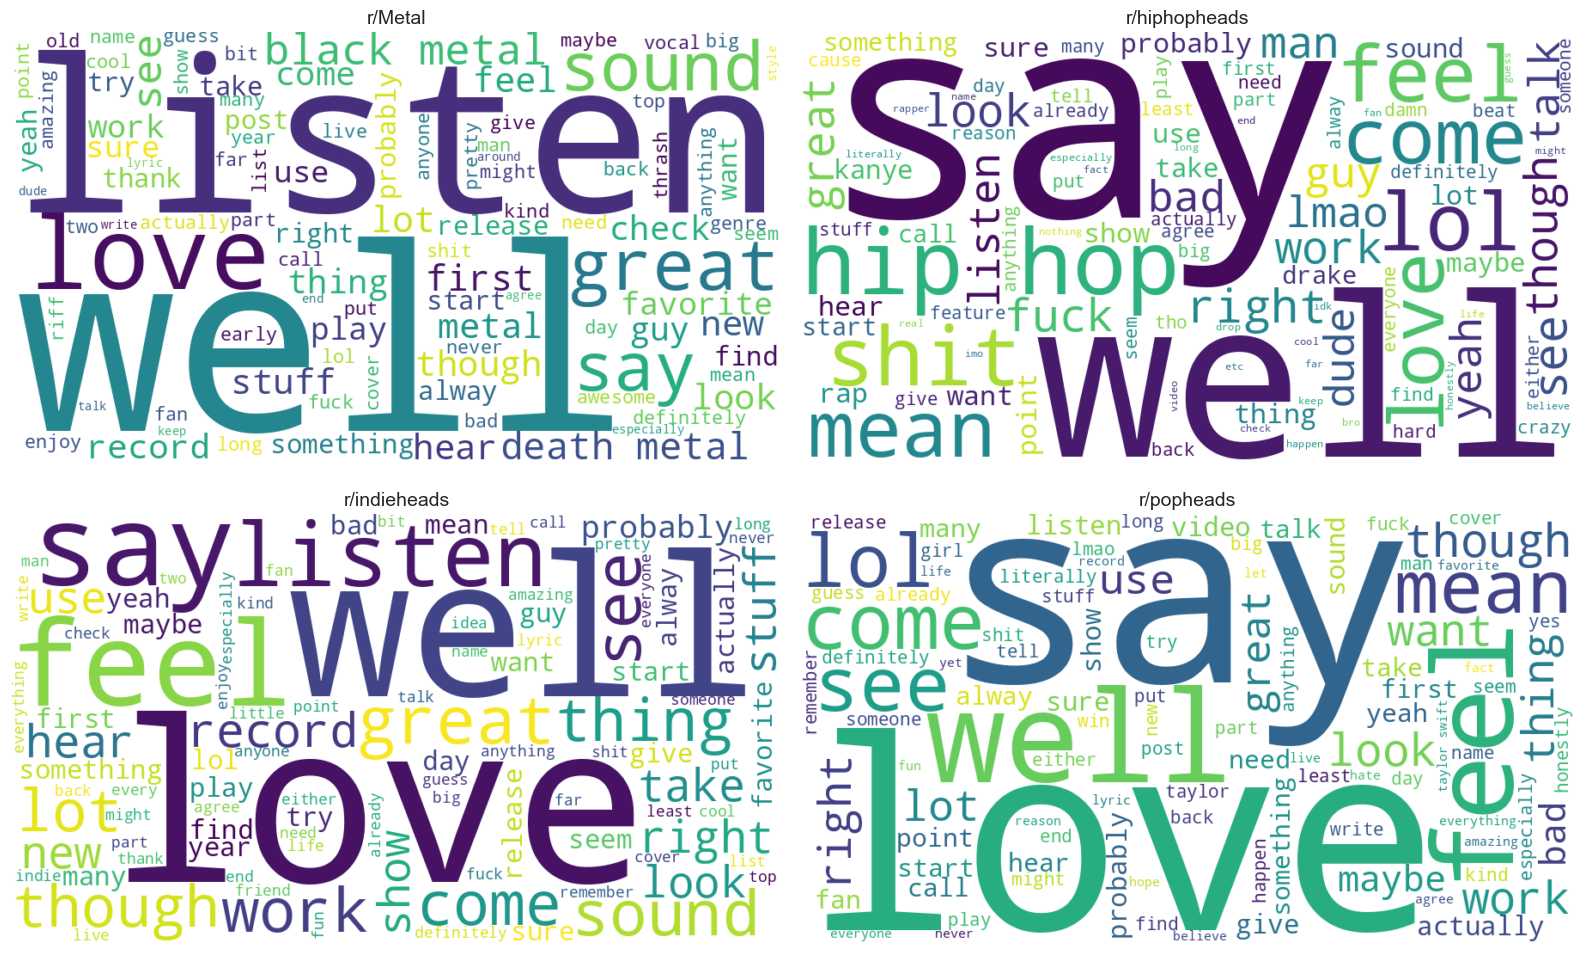

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (subreddit, group) in zip(axes, df.groupby("subreddit")):
    text = " ".join(group["processed_text"])
    wordcloud = WordCloud(width=900, height=500, background_color="white", max_words=100).generate(text)
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"r/{subreddit}")

for ax in axes[df["subreddit"].nunique():]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretacja chmur słów

Chmury słów pokazują ogólny obraz języka używanego w społecznościach, ale należy interpretować je ostrożnie. Wielkość słowa wynika z częstości jego występowania, a nie z jego znaczenia w dyskusji. Dlatego chmury słów najlepiej traktować jako uzupełnienie tabel i wykresów częstości oraz TF-IDF.

## 7. Analiza sentymentu VADER

Do analizy sentymentu wykorzystano VADER, czyli narzędzie przystosowane do krótkich wypowiedzi internetowych. Wynik `compound` przyjmuje wartości od -1 do 1, gdzie wartości ujemne oznaczają wypowiedzi bardziej negatywne, wartości dodatnie bardziej pozytywne, a okolice zera wskazują neutralność.

In [26]:
analyzer = SentimentIntensityAnalyzer()

df["sentiment"] = df["body"].map(lambda text: analyzer.polarity_scores(str(text))["compound"])


def classify_sentiment(score: float) -> str:
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"


df["sentiment_label"] = df["sentiment"].map(classify_sentiment)

sentiment_stats = (
    df.groupby("subreddit")["sentiment"]
    .agg(mean="mean", median="median", std="std", min="min", max="max", count="count")
    .round(3)
    .reset_index()
)

sentiment_distribution = (
    df.groupby(["subreddit", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
)

sentiment_distribution_percent = (
    sentiment_distribution
    .div(sentiment_distribution.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)

sentiment_stats.to_csv(REPORTS_DIR / "sentiment_stats_by_subreddit.csv", index=False)
sentiment_distribution_percent.to_csv(REPORTS_DIR / "sentiment_distribution_percent.csv")

display(sentiment_stats)
display(sentiment_distribution_percent)

,subreddit,mean,median,std,min,max,count
0,Metal,0.238,0.340,0.521,-1.0,1.0,105102
1,hiphopheads,0.118,0.000,0.498,-1.0,1.0,1248701
2,indieheads,0.289,0.361,0.492,-1.0,1.0,360392
3,popheads,0.248,0.318,0.514,-1.0,1.0,756319


sentiment_label,negative,neutral,positive
subreddit,,,
Metal,23.7,17.2,59.1
hiphopheads,29.2,23.3,47.6
indieheads,19.6,19.6,60.8
popheads,22.9,18.9,58.3


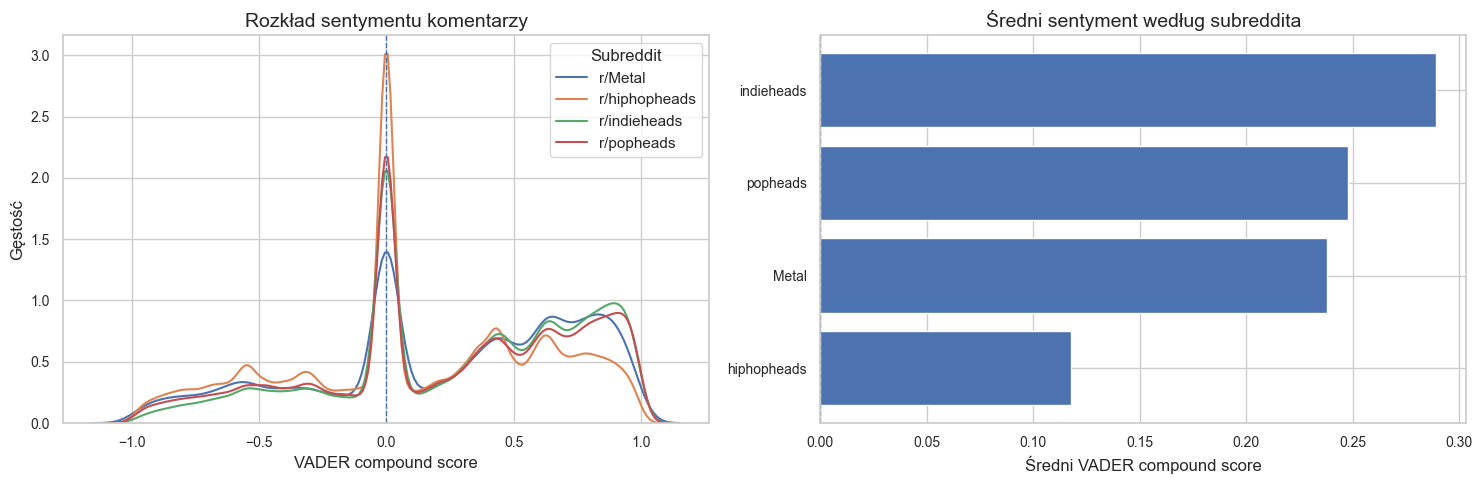

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for subreddit, group in df.groupby("subreddit"):
    sns.kdeplot(data=group, x="sentiment", label=f"r/{subreddit}", ax=axes[0], fill=False)

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].set_title("Rozkład sentymentu komentarzy")
axes[0].set_xlabel("VADER compound score")
axes[0].set_ylabel("Gęstość")
axes[0].legend(title="Subreddit")

means = sentiment_stats.sort_values("mean")
axes[1].barh(means["subreddit"], means["mean"])
axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].set_title("Średni sentyment według subreddita")
axes[1].set_xlabel("Średni VADER compound score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_sentiment_summary.png", dpi=150, bbox_inches="tight")
plt.show()

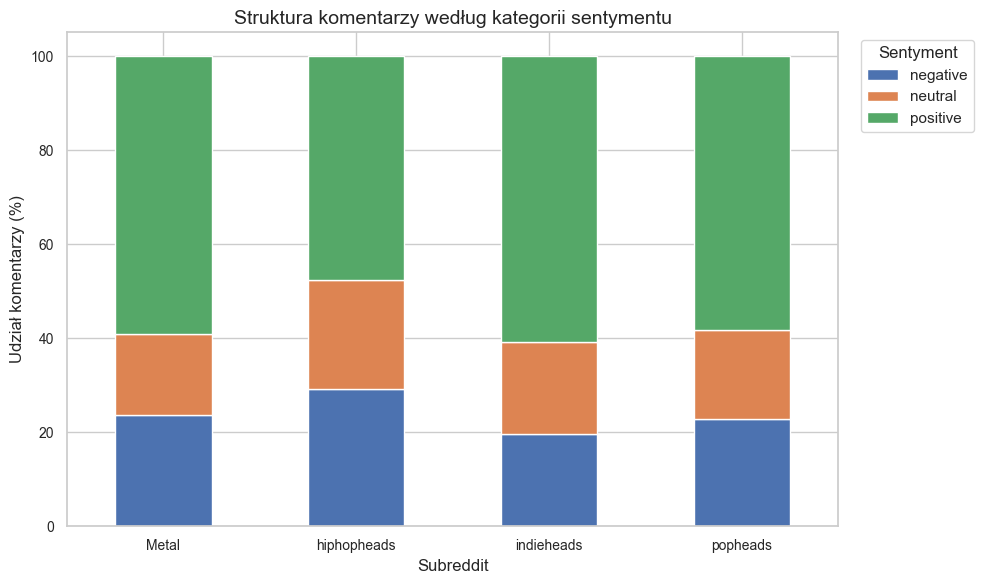

In [28]:
sentiment_distribution_percent[[col for col in ["negative", "neutral", "positive"] if col in sentiment_distribution_percent.columns]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.title("Struktura komentarzy według kategorii sentymentu")
plt.xlabel("Subreddit")
plt.ylabel("Udział komentarzy (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentyment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "text_mining_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretacja sentymentu

Porównanie średnich wartości sentymentu pozwala ocenić, które społeczności używają bardziej pozytywnego lub bardziej krytycznego języka. Rozkład kategorii pozytywnych, neutralnych i negatywnych pokazuje natomiast, czy różnice wynikają z ogólnego przesunięcia nastroju, czy z większego udziału skrajnych wypowiedzi. W kontekście społeczności muzycznych wyniki mogą zależeć od charakteru dyskusji: recenzje, spory o artystów, rekomendacje i reakcje na premiery mogą generować odmienne profile emocjonalne.

## 8. Modelowanie tematów LDA

Do identyfikacji głównych obszarów tematycznych wykorzystano model LDA. Liczba tematów została ustawiona na 7, ponieważ jest to kompromis między czytelnością interpretacji a możliwością uchwycenia kilku różnych wątków dyskusji. Przy mniejszej liczbie tematów model może nadmiernie łączyć różne obszary, a przy większej liczbie tematów wyniki mogą stać się trudniejsze do ręcznej interpretacji.

Dodatkowo obliczana jest miara coherence, która pomaga ocenić spójność tematów. Wyniki LDA należy jednak traktować jako narzędzie eksploracyjne, a nie jednoznaczny podział treści.

In [16]:
from tqdm import tqdm
import time

NUM_TOPICS = 7
NUM_WORDS = 10
LDA_SAMPLE_PER_SUBREDDIT = 10_000

lda_results = {}
lda_topic_rows = []
coherence_rows = []


def build_lda_for_group(
    tokens_list: list[list[str]],
    num_topics: int = NUM_TOPICS
):
    tokens_list = [
        tokens for tokens in tokens_list
        if isinstance(tokens, list) and len(tokens) >= 5
    ]

    if len(tokens_list) == 0:
        return None, None, None, None, None

    dictionary = corpora.Dictionary(tokens_list)

    dictionary.filter_extremes(
        no_below=10,
        no_above=0.4,
        keep_n=15_000
    )

    corpus = [
        dictionary.doc2bow(tokens)
        for tokens in tokens_list
    ]

    if len(dictionary) == 0 or len(corpus) == 0:
        return None, None, None, None, None

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=3,
        iterations=50,
        chunksize=2000,
        alpha="auto",
        eta="auto",
        per_word_topics=False,
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=tokens_list,
        dictionary=dictionary,
        coherence="c_v",
        processes=1
    )

    coherence = coherence_model.get_coherence()

    return lda_model, corpus, dictionary, tokens_list, coherence


start_time = time.time()

for subreddit, group in tqdm(
    df.groupby("subreddit"),
    desc="LDA by subreddit"
):
    print(f"\nProcessing subreddit: {subreddit}")

    group_for_lda = (
        group[group["tokens"].map(lambda x: isinstance(x, list) and len(x) >= 5)]
        .sample(
            n=min(LDA_SAMPLE_PER_SUBREDDIT, len(group)),
            random_state=42
        )
        .copy()
    )

    print(f"Documents used for LDA: {len(group_for_lda):,}")

    result = build_lda_for_group(
        group_for_lda["tokens"].tolist()
    )

    if result[0] is None:
        print(f"Skipped {subreddit} — not enough valid tokens.")
        continue

    lda_model, corpus, dictionary, tokens_list, coherence = result

    lda_results[subreddit] = {
        "model": lda_model,
        "corpus": corpus,
        "dictionary": dictionary,
        "tokens_list": tokens_list,
        "coherence": coherence,
    }

    coherence_rows.append({
        "subreddit": subreddit,
        "num_topics": NUM_TOPICS,
        "documents_used": len(tokens_list),
        "dictionary_size": len(dictionary),
        "coherence_cv": round(coherence, 3)
    })

    for topic_id in range(NUM_TOPICS):
        top_words_topic = lda_model.show_topic(
            topic_id,
            topn=NUM_WORDS
        )

        lda_topic_rows.append({
            "subreddit": subreddit,
            "topic_id": topic_id + 1,
            "proposed_topic_name": f"Temat {topic_id + 1} — do interpretacji ręcznej",
            "top_words": ", ".join([
                word for word, _ in top_words_topic
            ]),
            "weights": ", ".join([
                str(round(weight, 4))
                for _, weight in top_words_topic
            ])
        })

elapsed = time.time() - start_time
print(f"\nLDA finished in {elapsed / 60:.2f} minutes.")

lda_topics = pd.DataFrame(lda_topic_rows)
lda_coherence = pd.DataFrame(coherence_rows)

lda_topics.to_csv(
    REPORTS_DIR / "lda_topics_by_subreddit.csv",
    index=False
)

lda_coherence.to_csv(
    REPORTS_DIR / "lda_coherence_by_subreddit.csv",
    index=False
)

display(lda_coherence)
display(lda_topics)

LDA by subreddit:   0%|          | 0/4 [00:00<?, ?it/s]


Processing subreddit: Metal
Documents used for LDA: 10,000


LDA by subreddit:  25%|██▌       | 1/4 [00:08<00:25,  8.45s/it]


Processing subreddit: hiphopheads
Documents used for LDA: 10,000


LDA by subreddit:  50%|█████     | 2/4 [00:14<00:14,  7.29s/it]

...


Processing subreddit: popheads
Documents used for LDA: 10,000


LDA by subreddit: 100%|██████████| 4/4 [00:28<00:00,  7.22s/it]


LDA finished in 0.48 minutes.


,subreddit,num_topics,documents_used,dictionary_size,coherence_cv
0,Metal,7,10000,2492,0.514
1,hiphopheads,7,10000,2122,0.471
2,indieheads,7,10000,2549,0.494
3,popheads,7,10000,2648,0.496


,subreddit,topic_id,proposed_topic_name,top_words,weights
0,Metal,1,Temat 1 — do interpretacji ręcznej,"year, see, listen, hear, great, come, well, la...","0.0183, 0.0167, 0.0161, 0.011, 0.0107, 0.0098,..."
1,Metal,2,Temat 2 — do interpretacji ręcznej,"metal, death, black, sound, love, brutal, riff...","0.0387, 0.0222, 0.0092, 0.0076, 0.0075, 0.007,..."
2,Metal,3,Temat 3 — do interpretacji ręcznej,"metal, lot, listen, black, new, find, genre, s...","0.0524, 0.0128, 0.0126, 0.0122, 0.0103, 0.0093..."
3,Metal,4,Temat 4 — do interpretacji ręcznej,"post, see, well, vote, day, want, say, mean, n...","0.0164, 0.0159, 0.0079, 0.0069, 0.0067, 0.0066..."
4,Metal,5,Temat 5 — do interpretacji ręcznej,"great, iron, hell, maiden, favorite, man, ligh...","0.0111, 0.0111, 0.0105, 0.0095, 0.0087, 0.0085..."
5,Metal,6,Temat 6 — do interpretacji ręcznej,"death, metal, black, doom, thrash, vocal, soun...","0.0438, 0.0381, 0.0211, 0.0154, 0.0151, 0.0141..."
6,Metal,7,Temat 7 — do interpretacji ręcznej,"release, new, check, listen, first, record, lo...","0.0254, 0.0235, 0.0165, 0.0164, 0.0157, 0.0142..."
7,hiphopheads,1,Temat 1 — do interpretacji ręcznej,"listen, say, shit, first, verse, thing, bad, r...","0.0143, 0.0137, 0.0113, 0.0109, 0.01, 0.0096, ..."
8,hiphopheads,2,Temat 2 — do interpretacji ręcznej,"sound, listen, beat, project, year, great, fee...","0.0157, 0.0155, 0.0153, 0.015, 0.0146, 0.0141,..."
9,hiphopheads,3,Temat 3 — do interpretacji ręcznej,"never, well, say, shit, big, could, rapper, co...","0.0098, 0.0095, 0.0078, 0.0076, 0.0073, 0.0073..."


In [ ]:
# Save LDA results checkpoint

import pickle
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
lda_checkpoint_path = CHECKPOINT_DIR / "lda_results_checkpoint.pkl"
with open(lda_checkpoint_path, "wb") as handle:
    pickle.dump({
        "lda_results": lda_results,
        "lda_topics": lda_topics,
        "lda_coherence": lda_coherence,
    }, handle)
print(f"Zapisano wyniki LDA do: {lda_checkpoint_path}")
print(f"Liczba subredditów w lda_results: {len(lda_results)}")
print(f"lda_topics shape: {lda_topics.shape}")
print(f"lda_coherence shape: {lda_coherence.shape}")

In [ ]:
# Load LDA checkpoint

import pickle
from pathlib import Path

CHECKPOINT_DIR = Path("../data/checkpoints")

lda_checkpoint_path = CHECKPOINT_DIR / "lda_results_checkpoint.pkl"

print("Loading LDA checkpoint...")

with open(lda_checkpoint_path, "rb") as handle:
    checkpoint = pickle.load(handle)

lda_results = checkpoint["lda_results"]
lda_topics = checkpoint["lda_topics"]
lda_coherence = checkpoint["lda_coherence"]

print("LDA checkpoint loaded successfully.")

print(f"Liczba subredditów: {len(lda_results)}")

display(lda_coherence)
display(lda_topics.head())

Loading LDA checkpoint...
LDA checkpoint loaded successfully.
Liczba subredditów: 4


,subreddit,num_topics,documents_used,dictionary_size,coherence_cv
0,Metal,7,10000,2492,0.514
1,hiphopheads,7,10000,2122,0.471
2,indieheads,7,10000,2549,0.494
3,popheads,7,10000,2648,0.496


,subreddit,topic_id,proposed_topic_name,top_words,weights
0,Metal,1,Temat 1 — do interpretacji ręcznej,"year, see, listen, hear, great, come, well, la...","0.0183, 0.0167, 0.0161, 0.011, 0.0107, 0.0098,..."
1,Metal,2,Temat 2 — do interpretacji ręcznej,"metal, death, black, sound, love, brutal, riff...","0.0387, 0.0222, 0.0092, 0.0076, 0.0075, 0.007,..."
2,Metal,3,Temat 3 — do interpretacji ręcznej,"metal, lot, listen, black, new, find, genre, s...","0.0524, 0.0128, 0.0126, 0.0122, 0.0103, 0.0093..."
3,Metal,4,Temat 4 — do interpretacji ręcznej,"post, see, well, vote, day, want, say, mean, n...","0.0164, 0.0159, 0.0079, 0.0069, 0.0067, 0.0066..."
4,Metal,5,Temat 5 — do interpretacji ręcznej,"great, iron, hell, maiden, favorite, man, ligh...","0.0111, 0.0111, 0.0105, 0.0095, 0.0087, 0.0085..."


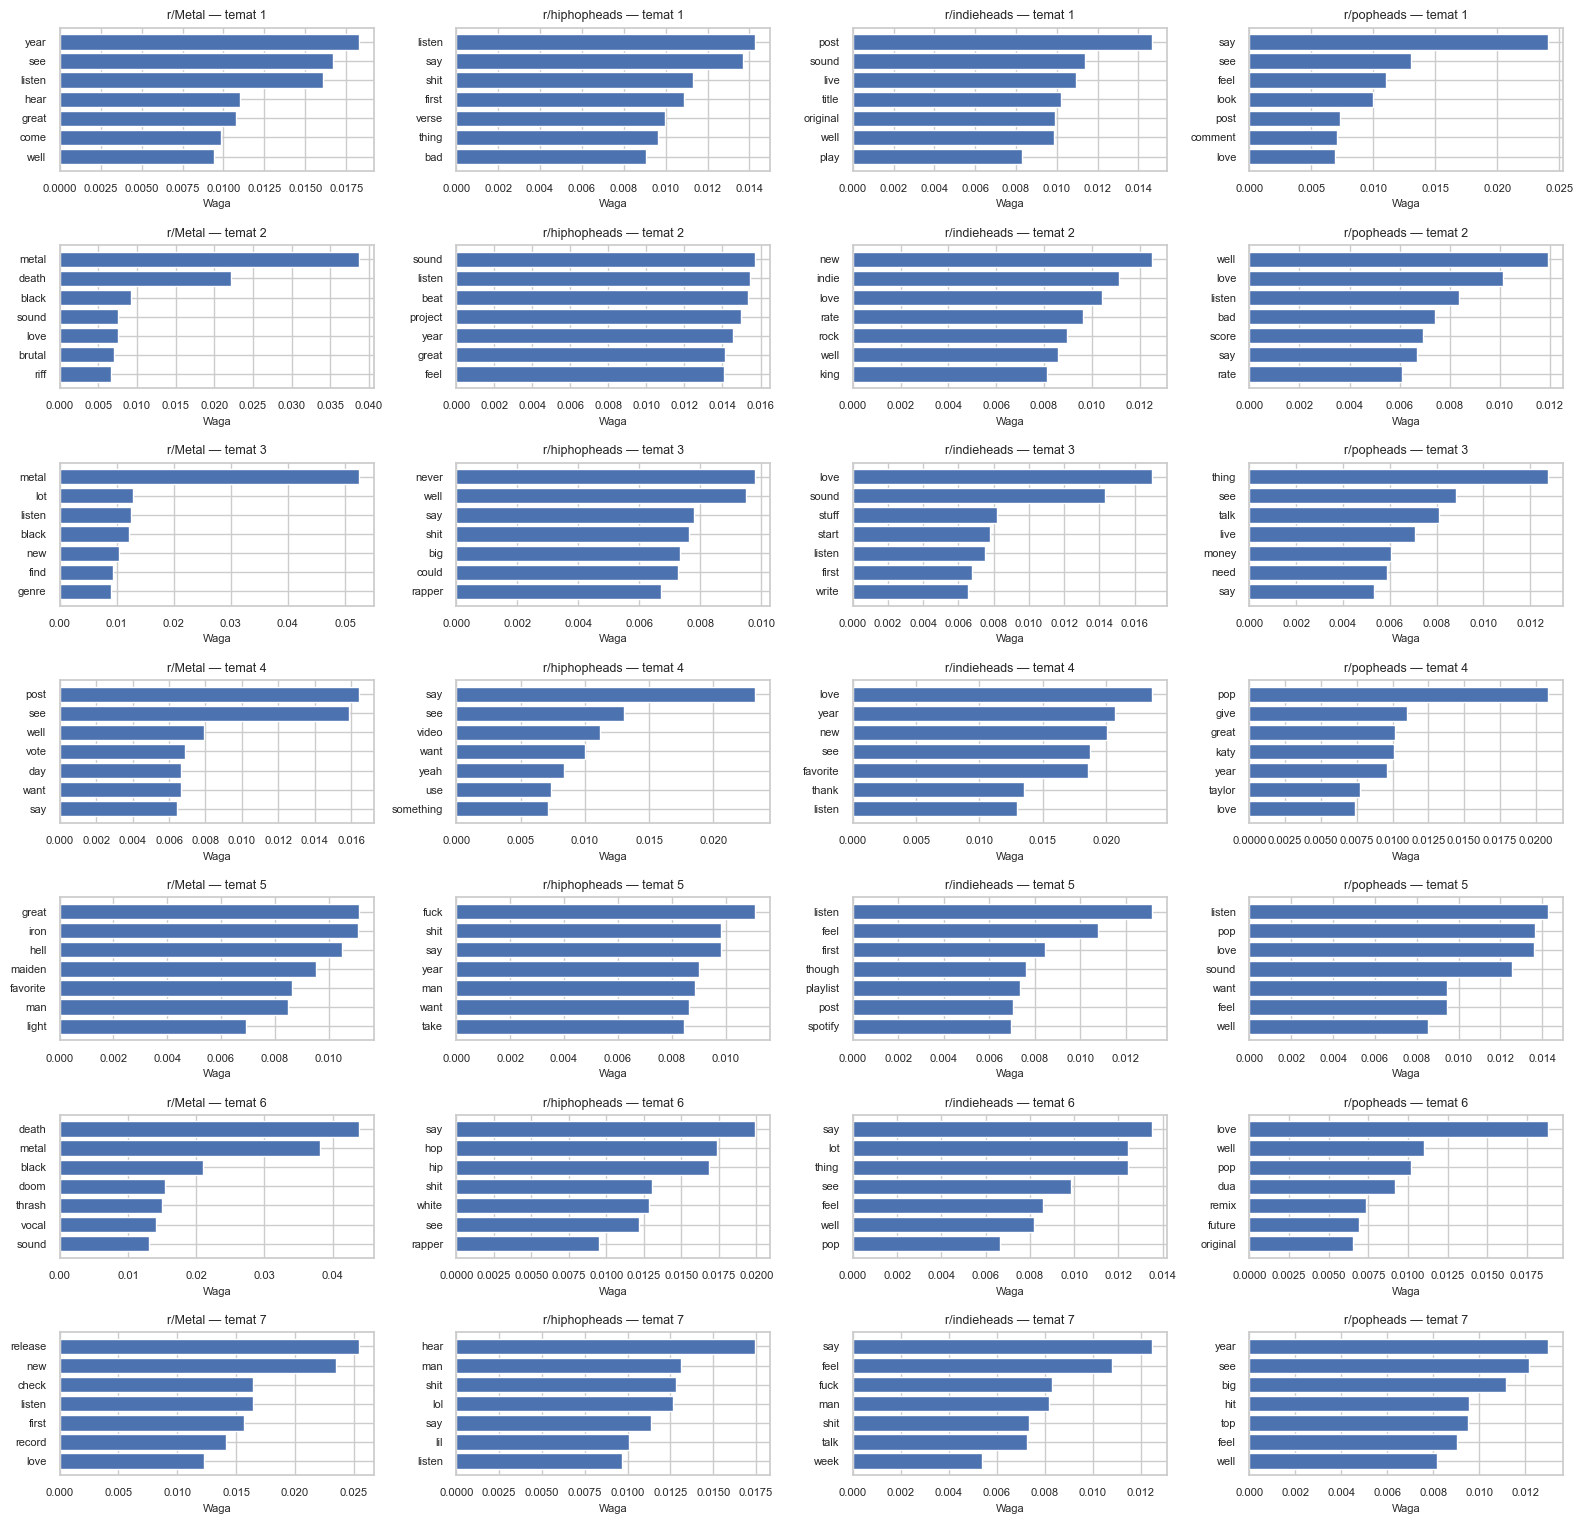

In [17]:
if lda_results:
    fig, axes = plt.subplots(NUM_TOPICS, len(lda_results), figsize=(4 * len(lda_results), 2.2 * NUM_TOPICS))

    if len(lda_results) == 1:
        axes = np.array(axes).reshape(NUM_TOPICS, 1)

    for col, (subreddit, result) in enumerate(lda_results.items()):
        lda_model = result["model"]
        for topic_id in range(NUM_TOPICS):
            ax = axes[topic_id, col]
            top = lda_model.show_topic(topic_id, topn=7)
            words = [word for word, _ in top][::-1]
            weights = [weight for _, weight in top][::-1]
            ax.barh(words, weights)
            ax.set_title(f"r/{subreddit} — temat {topic_id + 1}", fontsize=9)
            ax.set_xlabel("Waga", fontsize=8)
            ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "text_mining_lda_topics.png", dpi=150, bbox_inches="tight")
    plt.show()

,subreddit,topic_id,comment_count,share_percent
0,Metal,1,2966,29.7
1,Metal,2,775,7.8
2,Metal,3,1961,19.6
3,Metal,4,1171,11.7
4,Metal,5,539,5.4
5,Metal,6,1231,12.3
6,Metal,7,1357,13.6
7,hiphopheads,1,1303,13.0
8,hiphopheads,2,2158,21.6
9,hiphopheads,3,1190,11.9


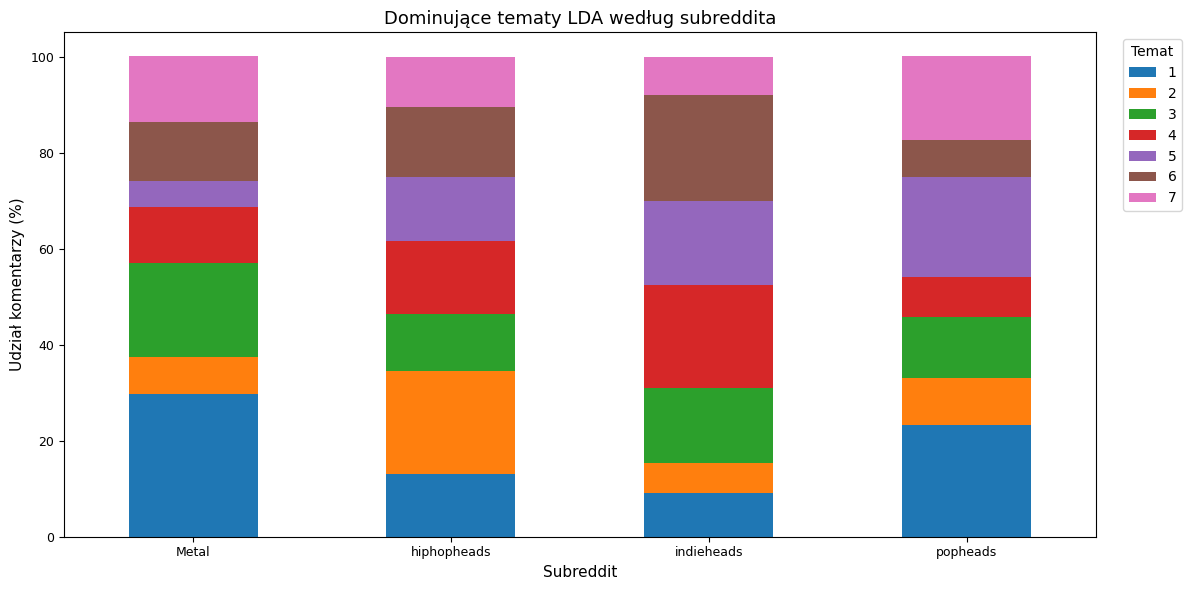

In [13]:
dominant_topic_rows = []

for subreddit, result in lda_results.items():
    lda_model = result["model"]
    corpus = result["corpus"]

    topic_counts = Counter()
    for bow in corpus:
        topic_distribution = lda_model.get_document_topics(bow)
        if topic_distribution:
            dominant_topic = max(topic_distribution, key=lambda item: item[1])[0] + 1
            topic_counts[dominant_topic] += 1

    total_docs = sum(topic_counts.values())
    for topic_id in range(1, NUM_TOPICS + 1):
        count = topic_counts.get(topic_id, 0)
        dominant_topic_rows.append({
            "subreddit": subreddit,
            "topic_id": topic_id,
            "comment_count": count,
            "share_percent": round((count / total_docs) * 100, 1) if total_docs else 0
        })

dominant_topics = pd.DataFrame(dominant_topic_rows)
dominant_topics.to_csv(REPORTS_DIR / "lda_dominant_topics_by_subreddit.csv", index=False)
display(dominant_topics)

if not dominant_topics.empty:
    pivot = dominant_topics.pivot(index="subreddit", columns="topic_id", values="share_percent")
    pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title("Dominujące tematy LDA według subreddita")
    plt.xlabel("Subreddit")
    plt.ylabel("Udział komentarzy (%)")
    plt.xticks(rotation=0)
    plt.legend(title="Temat", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "text_mining_lda_dominant_topics.png", dpi=150, bbox_inches="tight")
    plt.show()

### Interpretacja tematów LDA

Tabela tematów zawiera najważniejsze słowa przypisane do każdego tematu. Kolumna `proposed_topic_name` została celowo przygotowana do ręcznej interpretacji, ponieważ nazwanie tematów wymaga oceny badacza. Przykładowo temat zawierający słowa związane z premierami, datami i wydawnictwami można opisać jako „nowe wydania”, natomiast temat oparty na nazwach wykonawców może wskazywać na dyskusje fanowskie wokół konkretnych artystów.

Rozkład dominujących tematów według subredditów pozwala sprawdzić, czy różne społeczności koncentrują się na podobnych typach dyskusji, czy też mają odmienne profile tematyczne. W interpretacji należy jednak pamiętać, że LDA identyfikuje współwystępowanie słów, a nie pełne znaczenie wypowiedzi.

## 9. Ograniczenia analizy

Analiza text mining ma kilka istotnych ograniczeń:

- VADER dobrze sprawdza się w krótkich tekstach internetowych, ale może słabiej rozpoznawać ironię, sarkazm i kontekst kulturowy.
- Język Reddita zawiera slang, skróty, memy, nazwy własne i odniesienia środowiskowe, które nie zawsze są poprawnie interpretowane przez standardowe narzędzia NLP.
- LDA traktuje dokumenty jako zbiory słów i nie rozumie kolejności zdań ani głębszego kontekstu wypowiedzi.
- Wyniki TF-IDF zależą od zakresu korpusu oraz zastosowanej listy stopwords.
- Ręczne nazwanie tematów LDA ma charakter interpretacyjny i może zależeć od wiedzy badacza o danej społeczności muzycznej.
- Komentarze z Reddita nie muszą reprezentować całej społeczności fanów danego gatunku muzycznego, lecz aktywnych użytkowników konkretnej platformy.

## 10. Wnioski z analizy text mining

Analiza NLP pozwala porównać społeczności muzyczne Reddita pod względem języka, nastroju i dominujących tematów. Najczęstsze słowa i bigramy pokazują podstawowe różnice w słownictwie, natomiast TF-IDF wskazuje terminy szczególnie charakterystyczne dla poszczególnych subredditów. Analiza sentymentu umożliwia ocenę ogólnego tonu wypowiedzi, ale jej wyniki powinny być interpretowane ostrożnie ze względu na ironię i slang. Modelowanie LDA dostarcza dodatkowego wglądu w strukturę tematów, lecz wymaga ręcznego nazwania i krytycznej interpretacji.

Wyniki tej części projektu stanowią podstawę do dalszego porównania społeczności muzycznych oraz mogą zostać zestawione z analizą sieciową, aby sprawdzić, czy różnice językowe i tematyczne wiążą się ze strukturą interakcji między użytkownikami.

# Technical utilities and checkpoints

In [18]:
# =========================================================
# RESTORE NOTEBOOK ENVIRONMENT AFTER KERNEL RESTART
# =========================================================

# =========================
# Imports
# =========================

import re
import time
import pickle
import warnings

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

warnings.filterwarnings("ignore")

# =========================
# Directories
# =========================

BASE_DIR = Path("..")

DATA_DIR = BASE_DIR / "data"
OUTPUTS_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUTS_DIR / "figures"
REPORTS_DIR = OUTPUTS_DIR / "reports"

CHECKPOINT_DIR = DATA_DIR / "checkpoints"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Checkpoint paths
# =========================

RAW_CHECKPOINT = CHECKPOINT_DIR / "df_raw_checkpoint.pkl"

PREPROCESSED_CHECKPOINT = (
    CHECKPOINT_DIR / "df_preprocessed_checkpoint.pkl"
)

LDA_RESULTS_CHECKPOINT = (
    CHECKPOINT_DIR / "lda_results_checkpoint.pkl"
)

# =========================
# Notebook configuration
# =========================

NUM_TOPICS = 7
NUM_WORDS = 10

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# =========================
# NLP configuration
# =========================

base_stopwords = set(stopwords.words("english"))

extra_stopwords = {
    "like", "just", "get", "got", "one", "know",
    "think", "really", "would", "also", "even",
    "much", "still", "way", "good", "make",
    "people", "time", "music", "song", "songs",
    "album", "albums", "artist", "artists",
    "track", "tracks", "band", "bands",
    "https", "http", "www", "com",
    "reddit", "amp", "subreddit"
}

STOP_WORDS = base_stopwords | extra_stopwords

stemmer = PorterStemmer()

# =========================
# spaCy restore
# =========================

USE_SPACY = False
nlp = None

try:
    import spacy

    nlp = spacy.load(
        "en_core_web_sm",
        disable=["parser", "ner"]
    )

    USE_SPACY = True

except Exception:
    USE_SPACY = False
    nlp = None

# =========================
# Restore checkpoints
# =========================

df_raw = None
df = None

lda_results = {}
lda_topics = None
lda_coherence = None

# ---- RAW DATA ----

if RAW_CHECKPOINT.exists():

    print("Loading df_raw checkpoint...")

    df_raw = pd.read_pickle(
        RAW_CHECKPOINT
    )

    print(f"df_raw loaded: {df_raw.shape}")

else:
    print("Raw checkpoint not found.")

# ---- PREPROCESSED DATA ----

if PREPROCESSED_CHECKPOINT.exists():

    print("Loading preprocessed dataframe checkpoint...")

    df = pd.read_pickle(
        PREPROCESSED_CHECKPOINT
    )

    print(f"Preprocessed df loaded: {df.shape}")

    print("Available columns:")
    print(df.columns.tolist())

else:
    print("Preprocessed checkpoint not found.")

# ---- LDA RESULTS ----

if LDA_RESULTS_CHECKPOINT.exists():

    print("Loading LDA checkpoint...")

    with open(
        LDA_RESULTS_CHECKPOINT,
        "rb"
    ) as handle:

        checkpoint = pickle.load(handle)

    lda_results = checkpoint.get(
        "lda_results",
        {}
    )

    lda_topics = checkpoint.get(
        "lda_topics"
    )

    lda_coherence = checkpoint.get(
        "lda_coherence"
    )

    print(
        f"LDA checkpoint loaded. "
        f"Subreddits: {len(lda_results)}"
    )

    if hasattr(lda_topics, "shape"):
        print(
            f"lda_topics shape: "
            f"{lda_topics.shape}"
        )

    if hasattr(lda_coherence, "shape"):
        print(
            f"lda_coherence shape: "
            f"{lda_coherence.shape}"
        )

else:
    print("LDA checkpoint not found.")

# =========================
# Final status
# =========================

print("\n=========================")
print("Environment restored.")
print("=========================")

print(f"spaCy enabled: {USE_SPACY}")

print(f"Figures directory: {FIGURES_DIR}")
print(f"Reports directory: {REPORTS_DIR}")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

Loading df_raw checkpoint...
df_raw loaded: (2544183, 10)
Loading preprocessed dataframe checkpoint...
Preprocessed df loaded: (2470514, 14)
Available columns:
['comment_id', 'author', 'body', 'subreddit', 'score', 'created_utc', 'parent_id', 'link_id', 'controversiality', 'gilded', 'clean_text', 'tokens', 'processed_text', 'token_count']
Loading LDA checkpoint...
LDA checkpoint loaded. Subreddits: 4
lda_topics shape: (28, 5)
lda_coherence shape: (4, 5)

Environment restored.
spaCy enabled: True
Figures directory: ..\outputs\figures
Reports directory: ..\outputs\reports
Checkpoint directory: ..\data\checkpoints
